# Example-17: Virtual responce

In [1]:
# Import

import re
import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example virtual orbit responce matrix is computed
# Errors are introduced into standalone quadrupoles
# Transport matrices between monitors and correctors are computed using virtual phase and twiss
# One-step correction efficiency is compared

True


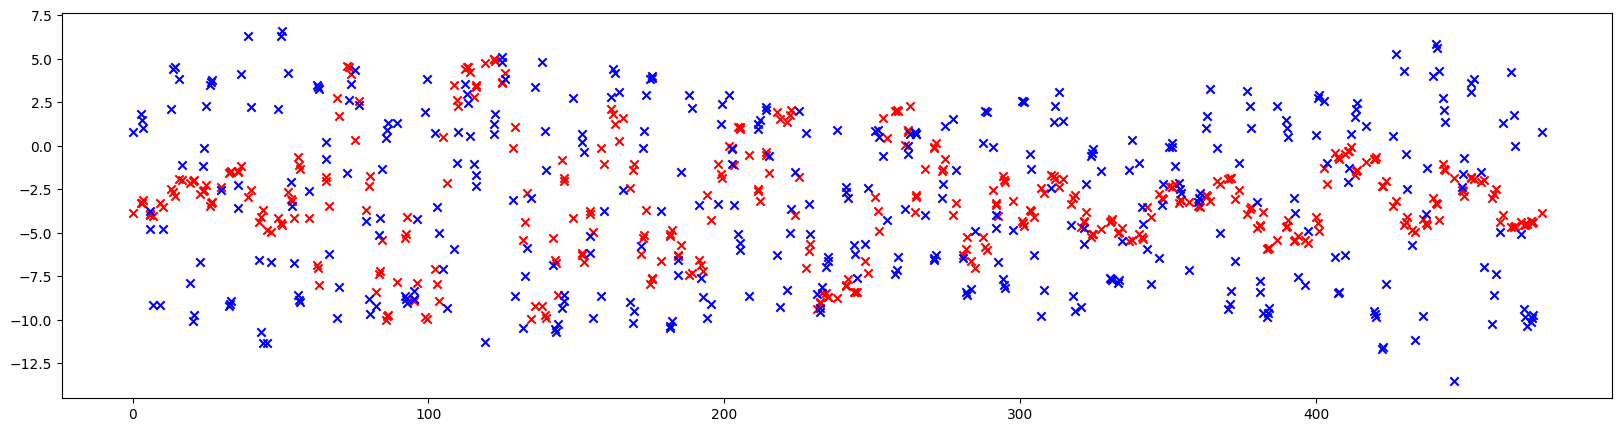

In [4]:
# Set model

model = Model(path='../fast.yaml', model='uncoupled', dtype=dtype, device=device)

# Set monitor locations (ID monitors)

lm = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.PKA[1, 2]', name)]

# Set fast corrector locations

lc = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.CB.*\.CX', name)]

# Set standalone quadrupole locations

lq = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.Q[F, D]', name)]

# Set quadrupole errors

kn = torch.zeros(model.size, dtype=dtype, device=device)
ks = torch.zeros(model.size, dtype=dtype, device=device)
kl = 0.0

kn[lq] += 1.0E-3*torch.randn(len(lq), dtype=dtype, device=device)
ks[lq] += 1.0E-3*torch.randn(len(lq), dtype=dtype, device=device)

# Set corrector errors

cx = torch.zeros(model.size, dtype=dtype, device=device)
cy = torch.zeros(model.size, dtype=dtype, device=device)

cx[lq] += 10.0E-6*torch.randn(len(lq), dtype=dtype, device=device)
cy[lq] += 10.0E-6*torch.randn(len(lq), dtype=dtype, device=device)

# Make errors

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)

# Make transport

model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

# Make twiss

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

NUX, NUY = model.out_tune_fractional

# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0]
N33 = model.out_normal[:, 2, 2]
N21 = model.out_normal[:, 1, 0]
N43 = model.out_normal[:, 3, 2]
N13 = model.out_normal[:, 0, 2]
N31 = model.out_normal[:, 2, 0]
N14 = model.out_normal[:, 0, 3]
N41 = model.out_normal[:, 3, 0]

# Set CS twiss

AX, BX, AY, BY = model.out_cs.T

# Set accumulated phase advance

MUX, MUY = model.out_advance.roll(1, 0).cumsum(0).T

# Compare twiss

plt.figure(figsize=(20, 5))
plt.scatter(model.time.cpu().numpy(), 100*(BX - model.bx)/model.bx, color='red', marker='x')
plt.scatter(model.time.cpu().numpy(), 100*(BY - model.by)/model.by, color='blue', marker='x')
plt.show()

In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.001, 0.0, 0.001, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**12

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[model.monitor_index, ..., 0]
y = trajectory[model.monitor_index, ..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[index], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

torch.Size([385, 4096, 4])

3.078581663e-08, 3.711582091e-19
2.104968623e-07, 5.795853369e-19



NUX= 0.814011047
nux= 0.814011047, sigma_nux=4.77867254e-16, error_nux=4.4408921e-15

NUY=  0.84389894
nuy=  0.84389894, sigma_nuy=1.31305314e-16, error_nuy=1.33226763e-15



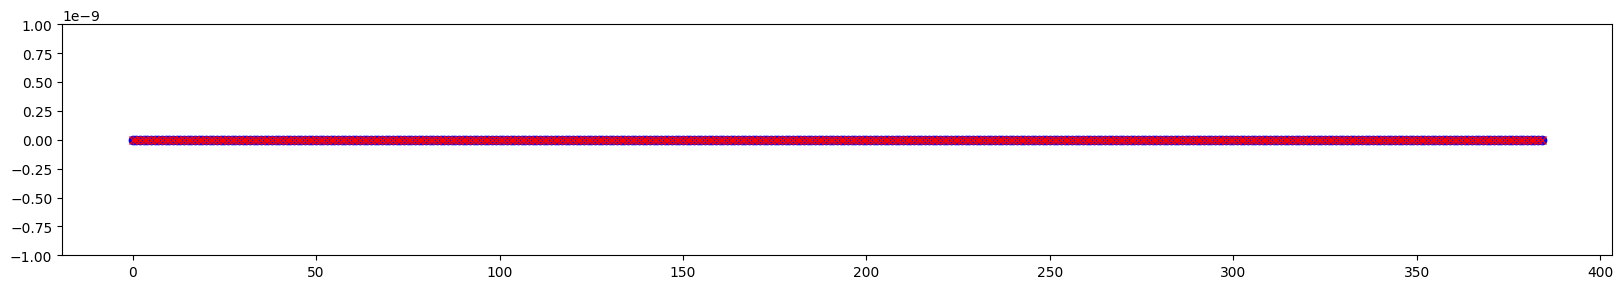

In [6]:
# Compute reference parameters from clean data at all locations

# Set window

win = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

# Estimate frequency, amplitude and phase for x plane

tbt = Data.from_data(win, trajectory[..., 0])

f = Frequency(tbt)
tbt.window_remove_mean()
tbt.window_apply()
f('parabola')
tbt.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')
print()

d = Decomposition(tbt)
ax_ref, sigma_ax, *_ = d.harmonic_amplitude(nux, length=2048, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=512, step=16, method='none')
fx_ref, sigma_fx, *_ = d.harmonic_phase(nux, length=2048, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=512, step=16, method='none')

# Estimate frequency, amplitude and phase for y plane

tbt = Data.from_data(win, trajectory[..., 2])

f = Frequency(tbt)
tbt.window_remove_mean()
tbt.window_apply()
f('parabola')
tbt.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')
print()

d = Decomposition(tbt)
ay_ref, sigma_ay, *_ = d.harmonic_amplitude(nuy, length=2048, order=2.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=512, step=16, method='none')
fy_ref, sigma_fy, *_ = d.harmonic_phase(nuy, length=2048, order=2.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=512, step=16, method='none')

# Phase advance between locations

plt.figure(figsize=(20, 3))

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX)
advance, _ = Decomposition.phase_adjacent(nux, fx_ref)

plt.errorbar(range(model.size), mod(ADVANCE - advance, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), fmt=' ', marker='o', color='blue')

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY)
advance, _ = Decomposition.phase_adjacent(nuy, fy_ref)

plt.errorbar(range(model.size), mod(ADVANCE - advance, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), fmt=' ', marker='x', color='red')

plt.ylim(-1.0E-9, +1.0E-9)
plt.hlines(0, 0, model.size - 1, colors='black')

plt.show()

In [7]:
# Generate TbT data with noise

# Set noise values for each monitor location 

noise_x = 1.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set length

length = 2**10

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x[:, :length])
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y[:, :length])
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(224, Window(1024, 'cosine_window', 1.0))
Data(224, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')
print()

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

print((ax - ax_ref[model.monitor_index]).abs().sum().item())
print((fx - fx_ref[model.monitor_index]).abs().sum().item())

NUX= 0.814011047
nux= 0.814011041, sigma_nux=9.24829208e-08, error_nux=6.10542839e-09

1.4915440076482202e-05
0.019392947191505475


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')
print()

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

print((ay - ay_ref[model.monitor_index]).abs().sum().item())
print((fy - fy_ref[model.monitor_index]).abs().sum().item())

NUY=  0.84389894
nuy= 0.843898936, sigma_nuy=5.01489357e-08, error_nuy=3.82968701e-09

1.5885854796826625e-05
0.010841638067581694


In [10]:
# Set table

table = Table(
    model.monitor_name,
    nux, nuy, ax, ay, fx, fy,
    sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    accumulate=True,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(NUX, mux)
muy, _ = Decomposition.phase_adjacent(NUY, muy)

print((mux - table.phase_x).abs().sum().item())
print((muy - table.phase_y).abs().sum().item())
print()

0.02934046206830132
0.015987513382605734



In [11]:
# Set twiss

twiss = Twiss(model, table)

In [12]:
# Generate virtual signals

# Note, limit selection can be motivated by how accurate is the model
# Minimal value is one and it should be used if model if off
# Larger values can improve accuracy if model is more accurate

start = 1
count = length - 1 - start
limit = 1

VQX = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)
VPX = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)
VQY = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)
VPY = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)

for index, location in enumerate(model.virtual_index):
    
    qx, px, qy, py = twiss.get_momenta_lstsq(start, count, location, limit, model.matrix, phony=True, forward=True, inverse=True)
    
    VQX[index, :count] = qx
    VPX[index, :count] = px
    
    VQY[index, :count] = qy
    VPY[index, :count] = py

In [13]:
# Set TbT

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

X = Data.from_data(win, VQX)
Y = Data.from_data(win, VQY)

print(X)
print(Y)

Data(161, Window(1024, 'cosine_window', 1.0))
Data(161, Window(1024, 'cosine_window', 1.0))


In [14]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

# Shift phase

fx = mod(fx - 2.0*numpy.pi*start*nux, 2.0*numpy.pi, -numpy.pi)

NUX= 0.814011047
nux= 0.814011043, sigma_nux=6.71570468e-08, error_nux=3.40654494e-09


In [15]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

# Shift phase

fy = mod(fy - 2.0*numpy.pi*start*nuy, 2.0*numpy.pi, -numpy.pi)

NUY=  0.84389894
nuy= 0.843898933, sigma_nuy=4.2790582e-08, error_nuy=6.79224321e-09


In [16]:
# Set virtual phases

twiss.fx[model.virtual_index] = fx
twiss.fy[model.virtual_index] = fy

twiss.sigma_fx[model.virtual_index] = sigma_fx
twiss.sigma_fy[model.virtual_index] = sigma_fy

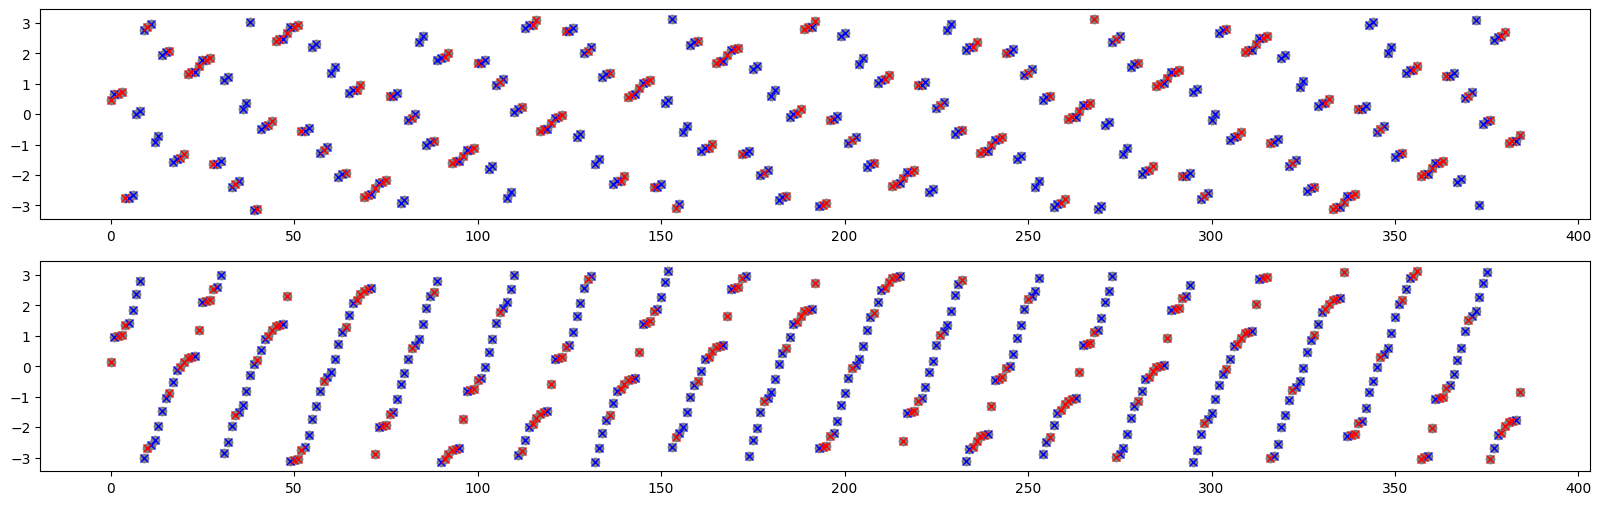

In [17]:
# Compare phases

plt.figure(figsize=(20, 2*3))

ax1 = plt.subplot(211)
ax1.scatter(range(model.size), fx_ref.cpu().numpy(), marker='o', color='gray')
ax1.errorbar(model.monitor_index, mod(twiss.fx[model.monitor_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax1.errorbar(model.virtual_index, mod(twiss.fx[model.virtual_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fx[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')

ax2 = plt.subplot(212)
ax2.scatter(range(model.size), fy_ref.cpu().numpy(), marker='o', color='gray')
ax2.errorbar(model.monitor_index, mod(twiss.fy[model.monitor_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fy[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax2.errorbar(model.virtual_index, mod(twiss.fy[model.virtual_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fy[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

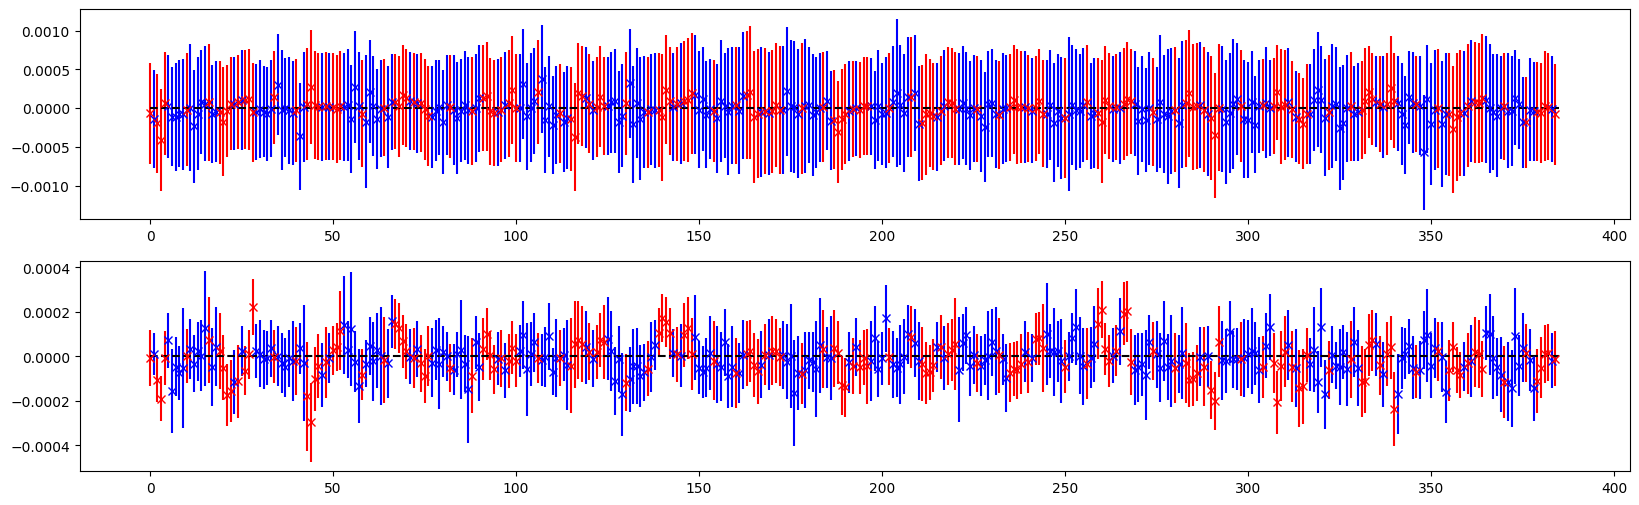

In [18]:
# Compare phases

plt.figure(figsize=(20, 2*3))

ax1 = plt.subplot(211)
ax1.errorbar(model.monitor_index, (fx_ref[model.monitor_index] - mod(twiss.fx[model.monitor_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax1.errorbar(model.virtual_index, (fx_ref[model.virtual_index] - mod(twiss.fx[model.virtual_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fx[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax1.hlines(0, 0, model.size, linestyles='dashed', color='black')

ax2 = plt.subplot(212)
ax2.errorbar(model.monitor_index, (fy_ref[model.monitor_index] - mod(twiss.fy[model.monitor_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fy[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax2.errorbar(model.virtual_index, (fy_ref[model.virtual_index] - mod(twiss.fy[model.virtual_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fy[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax2.hlines(0, 0, model.size, linestyles='dashed', color='black')

plt.show()

In [19]:
%%time

# Estimate twiss

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 product=True,
                                 jacobian=False,
                                 count=256,
                                 fraction=0.75,
                                 ix=None,
                                 iy=None,
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)

torch.Size([224, 2, 10, 256])
CPU times: user 5min 18s, sys: 37.7 s, total: 5min 56s
Wall time: 6min 58s


In [20]:
# Process fitted invariants

ix, iy = data[:, 0, 0], data[:, 0, 1]
sigma_ix, sigma_iy = data[:, 1, 0], data[:, 1, 1]
invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

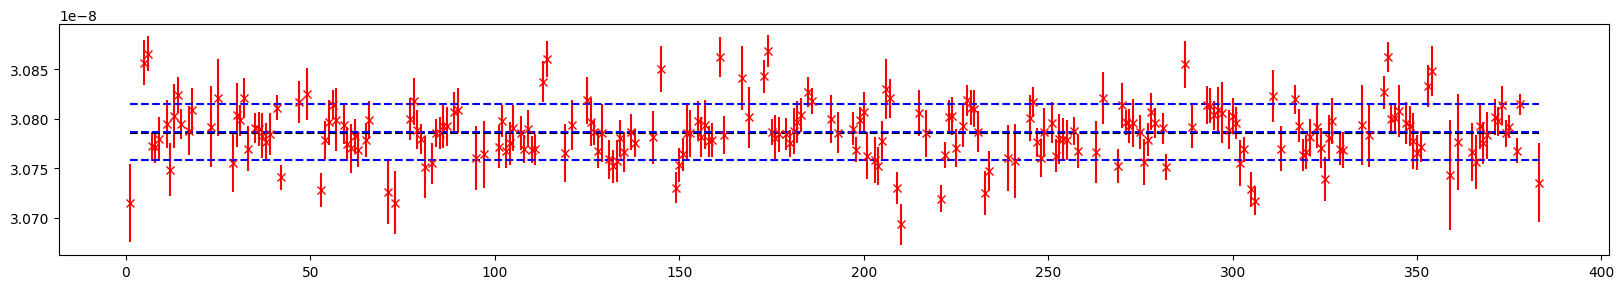

tensor(3.078581662772e-08, dtype=torch.float64)
tensor(3.078678778986e-08, dtype=torch.float64)
tensor(2.827340248710e-11, dtype=torch.float64)



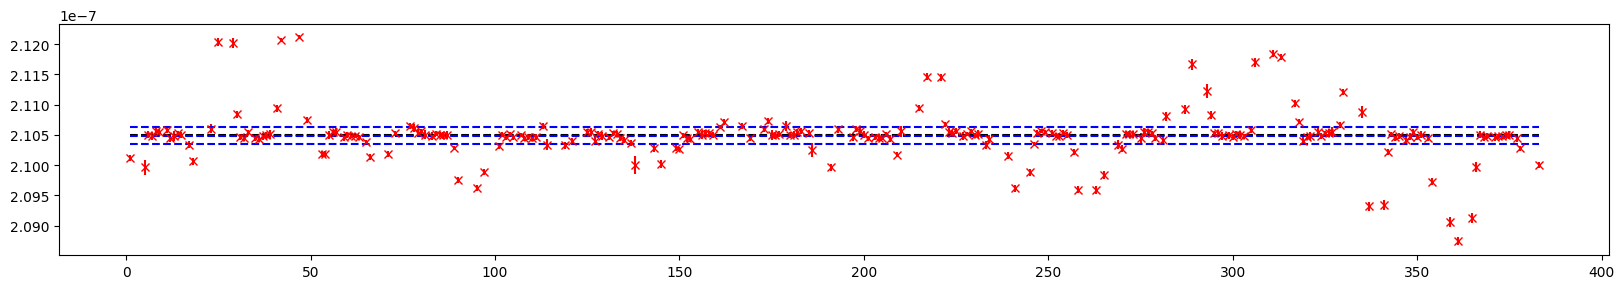

tensor(2.104968622913e-07, dtype=torch.float64)
tensor(2.104849313191e-07, dtype=torch.float64)
tensor(1.420292132103e-10, dtype=torch.float64)



In [21]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(model.monitor_index, invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(model.monitor_index, invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

In [22]:
# Process twiss

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value, error = data.permute(1, 2, 0, -1)

*_, value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41 = value
*_, error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41 = error

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

In [23]:
%%time

# Estimate twiss (virtual)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 phony=True,
                                 product=True,
                                 jacobian=False,
                                 count=256,
                                 fraction=0.75,
                                 ix=invariant['ix_value'],
                                 iy=invariant['iy_value'],
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)
print(model.virtual_count)

torch.Size([161, 2, 8, 256])
161
CPU times: user 3min 18s, sys: 25.6 s, total: 3min 44s
Wall time: 4min 19s


In [24]:
# Process twiss

value, error = data.permute(1, 2, 0, -1)

*_, value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41 = value
*_, error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41 = error

value_v11, error_v11 = twiss.process(value_v11, error_v11)
value_v33, error_v33 = twiss.process(value_v33, error_v33)
value_v21, error_v21 = twiss.process(value_v21, error_v21)
value_v43, error_v43 = twiss.process(value_v43, error_v43)
value_v13, error_v13 = twiss.process(value_v13, error_v13)
value_v31, error_v31 = twiss.process(value_v31, error_v31)
value_v14, error_v14 = twiss.process(value_v14, error_v14)
value_v41, error_v41 = twiss.process(value_v41, error_v41)

In [25]:
# Compute twiss at all locations from normalization

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_local, error_local in zip(value, error):
    table = value_local.reshape(-1, 1) + error_local.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax_m, value_bx_m, value_ay_m, value_by_m = cs_value.T
error_ax_m, error_bx_m, error_ay_m, error_by_m = cs_error.T

value = torch.stack([value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41]).T
error = torch.stack([error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41]).T

cs_value, cs_error = [], []

for value_local, error_local in zip(value, error):
    table = value_local.reshape(-1, 1) + error_local.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax_v, value_bx_v, value_ay_v, value_by_v = cs_value.T
error_ax_v, error_bx_v, error_ay_v, error_by_v = cs_error.T

In [26]:
# Set uncoupled

twiss.ax[model.monitor_index] = value_ax_m
twiss.bx[model.monitor_index] = value_bx_m
twiss.ay[model.monitor_index] = value_ay_m
twiss.by[model.monitor_index] = value_by_m

twiss.ax[model.virtual_index] = value_ax_v
twiss.bx[model.virtual_index] = value_bx_v
twiss.ay[model.virtual_index] = value_ay_v
twiss.by[model.virtual_index] = value_by_v

twiss.sigma_ax[model.monitor_index] = error_ax_m
twiss.sigma_bx[model.monitor_index] = error_bx_m
twiss.sigma_ay[model.monitor_index] = error_ay_m
twiss.sigma_by[model.monitor_index] = error_by_m

twiss.sigma_ax[model.virtual_index] = error_ax_v
twiss.sigma_bx[model.virtual_index] = error_bx_v
twiss.sigma_ay[model.virtual_index] = error_ay_v
twiss.sigma_by[model.virtual_index] = error_by_v

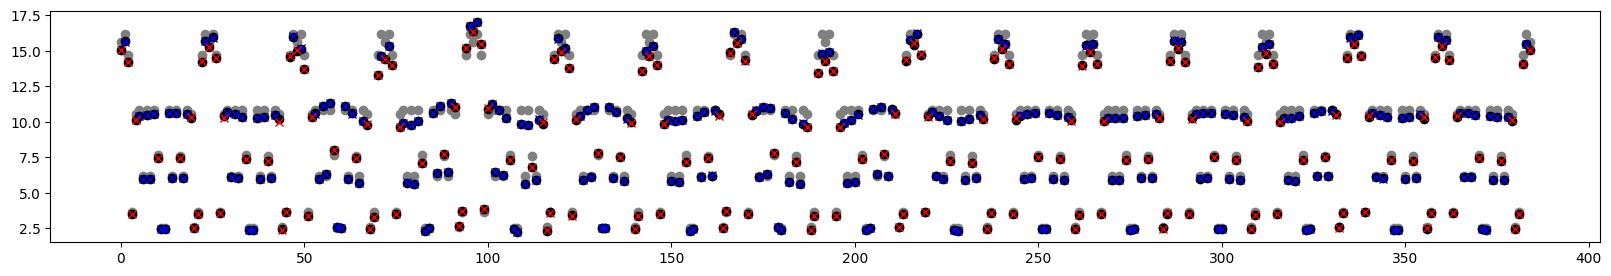

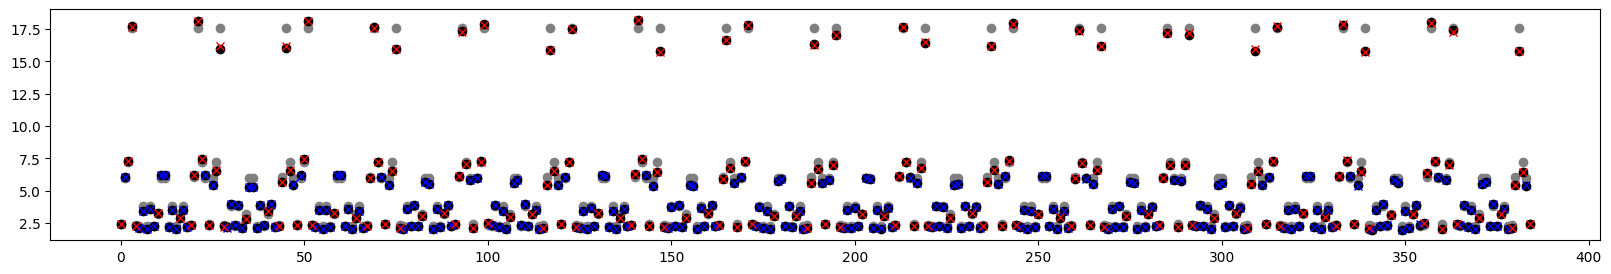

tensor(2.004022132716e-01, dtype=torch.float64)
tensor(1.327097591501e-03, dtype=torch.float64)

tensor(1.749554649340e-03, dtype=torch.float64)
tensor(3.647498799669e-02, dtype=torch.float64)



In [27]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.bx, color='gray', marker='o')
plt.scatter(range(model.size), BX, color='black', marker='o')
plt.errorbar(model.monitor_index, value_bx_m, yerr=error_bx_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_bx_v, yerr=error_bx_v, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.by, color='gray', marker='o')
plt.scatter(range(model.size), BY, color='black', marker='o')
plt.errorbar(model.monitor_index, value_by_m, yerr=error_by_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_by_v, yerr=error_by_v, fmt=' ', color='red', marker='x')
plt.show()

print((BX[model.monitor_index] - value_bx_m).sum().abs())
print((BX[model.virtual_index] - value_bx_v).sum().abs())
print()

print((BY[model.monitor_index] - value_by_m).sum().abs())
print((BY[model.virtual_index] - value_by_v).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

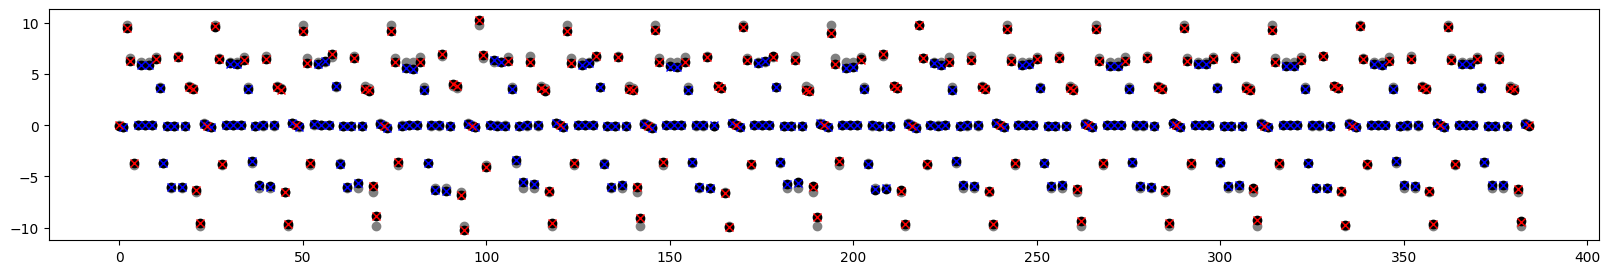

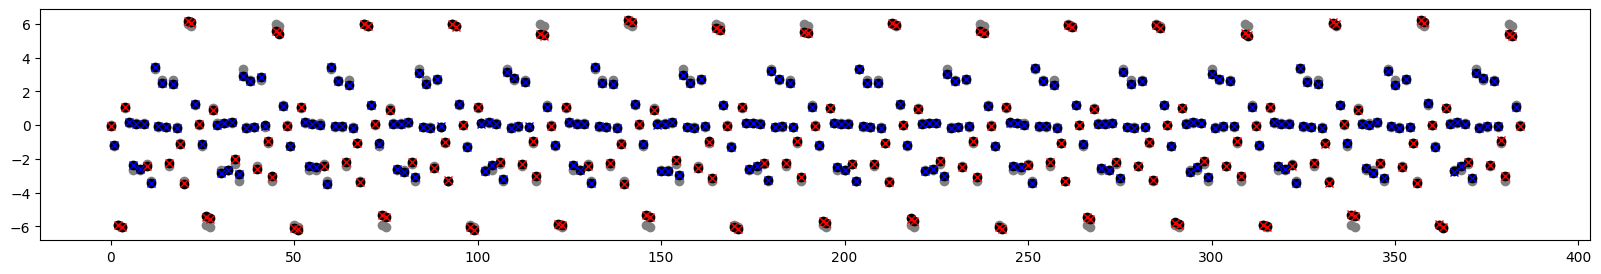

tensor(1.307742392937e-02, dtype=torch.float64)
tensor(2.163400537187e-01, dtype=torch.float64)

tensor(1.263960984283e-02, dtype=torch.float64)
tensor(4.821318063423e-03, dtype=torch.float64)



In [28]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ax, color='gray', marker='o')
plt.scatter(range(model.size), AX, color='black', marker='o')
plt.errorbar(model.monitor_index, value_ax_m, yerr=error_ax_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ax_v, yerr=error_ax_v, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ay, color='gray', marker='o')
plt.scatter(range(model.size), AY, color='black', marker='o')
plt.errorbar(model.monitor_index, value_ay_m, yerr=error_ay_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ay_v, yerr=error_ay_v, fmt=' ', color='red', marker='x')
plt.show()

print((AX[model.monitor_index] - value_ax_m).sum().abs())
print((AX[model.virtual_index] - value_ax_v).sum().abs())
print()

print((AY[model.monitor_index] - value_ay_m).sum().abs())
print((AY[model.virtual_index] - value_ay_v).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

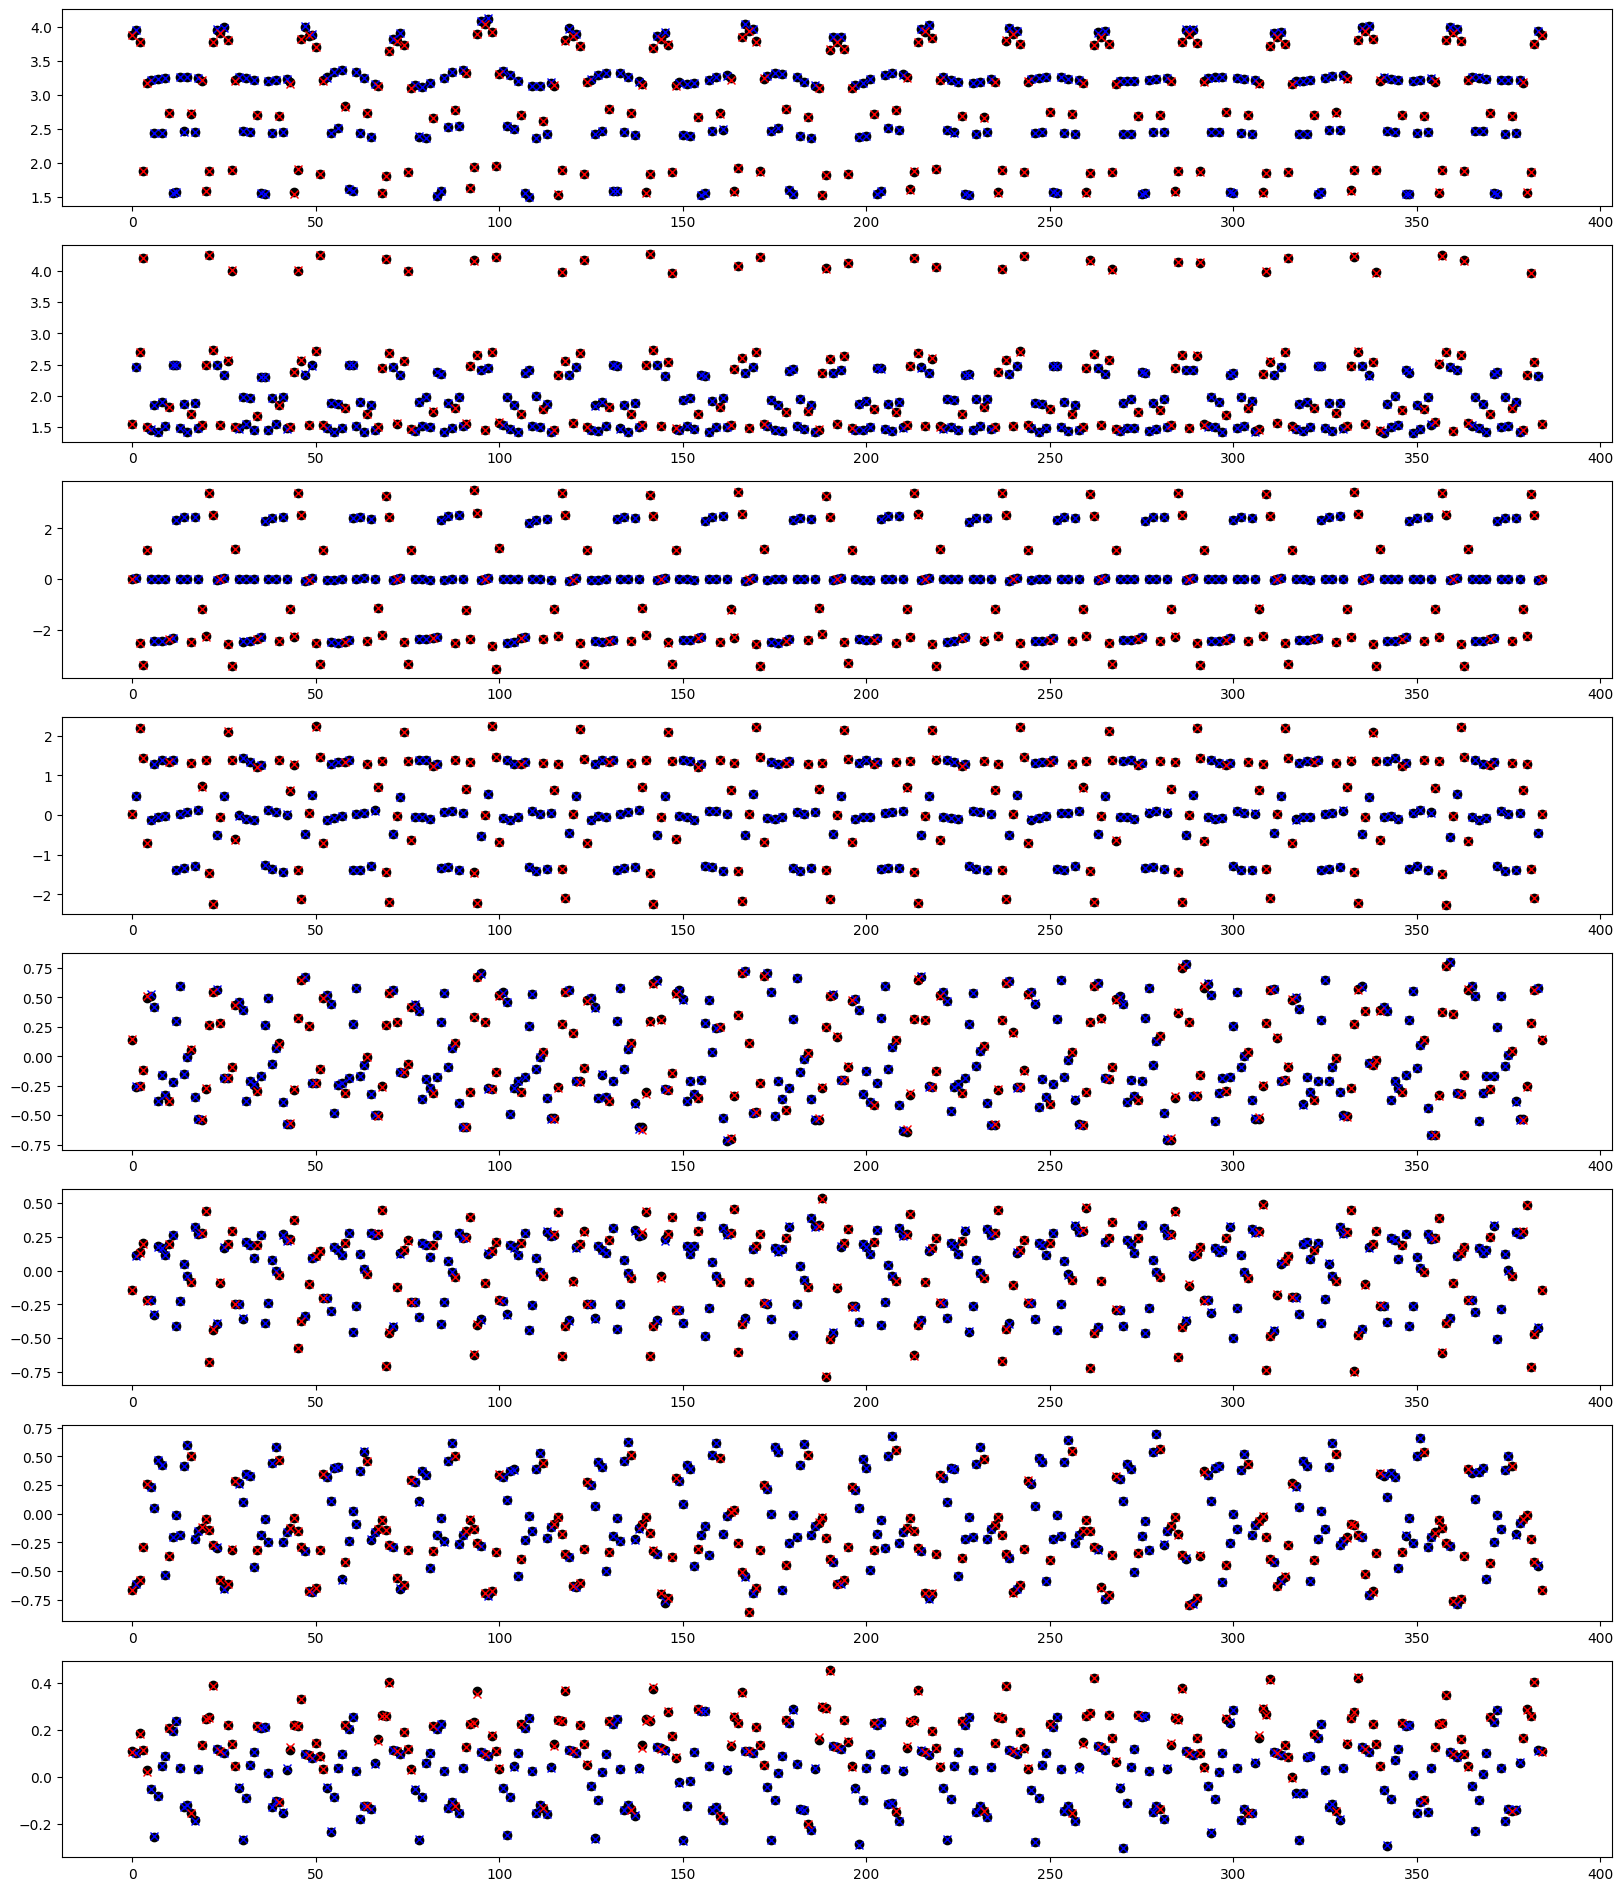

In [29]:
# Compare normalization matrix elements

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.size), N11, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n11, yerr=error_n11, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v11, yerr=error_v11, fmt=' ', color='red', marker='x')

ax = plt.subplot(812)
ax.scatter(range(model.size), N33, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n33, yerr=error_n33, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v33, yerr=error_v33, fmt=' ', color='red', marker='x')

ax = plt.subplot(813)
ax.scatter(range(model.size), N21, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n21, yerr=error_n21, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v21, yerr=error_v21, fmt=' ', color='red', marker='x')

ax = plt.subplot(814)
ax.scatter(range(model.size), N43, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n43, yerr=error_n43, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v43, yerr=error_v43, fmt=' ', color='red', marker='x')

ax = plt.subplot(815)
ax.scatter(range(model.size), N13, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n13, yerr=error_n13, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v13, yerr=error_v13, fmt=' ', color='red', marker='x')

ax = plt.subplot(816)
ax.scatter(range(model.size), N31, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n31, yerr=error_n31, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v31, yerr=error_v31, fmt=' ', color='red', marker='x')

ax = plt.subplot(817)
ax.scatter(range(model.size), N14, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n14, yerr=error_n14, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v14, yerr=error_v14, fmt=' ', color='red', marker='x')

ax = plt.subplot(818)
ax.scatter(range(model.size), N41, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n41, yerr=error_n41, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v41, yerr=error_v41, fmt=' ', color='red', marker='x')

plt.show()

# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [30]:
# Set normal at monitor locations

from harmonica.parameterization import parametric_normal
for index, (n11, n33, n21, n43, n13, n31, n14, n41) in enumerate(zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)):
    index = model.monitor_index[index]
    normal = parametric_normal(n11, n33, n21, n43, n13, n31, n14, n41, dtype=dtype)
    twiss.normal[index] = normal

# Set normal at virtual locations

from harmonica.parameterization import parametric_normal
for index, (n11, n33, n21, n43, n13, n31, n14, n41) in enumerate(zip(value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41)):
    index = model.virtual_index[index]
    normal = parametric_normal(n11, n33, n21, n43, n13, n31, n14, n41, dtype=dtype)
    twiss.normal[index] = normal

In [31]:
# Compute responce matrix using model transport

responce_model = model.make_responce(lc, lm, model.matrix)

In [32]:
# Compute responce matrix using error transport

responce_error = model.make_responce(lc, lm, model.matrix_transport)

In [33]:
# Compute responce matrix using virtual transport
# twiss.matrix or twiss.matrix_virtual

model.model = 'coupled'
responce_twiss = model.make_responce(lc, lm, twiss.matrix)

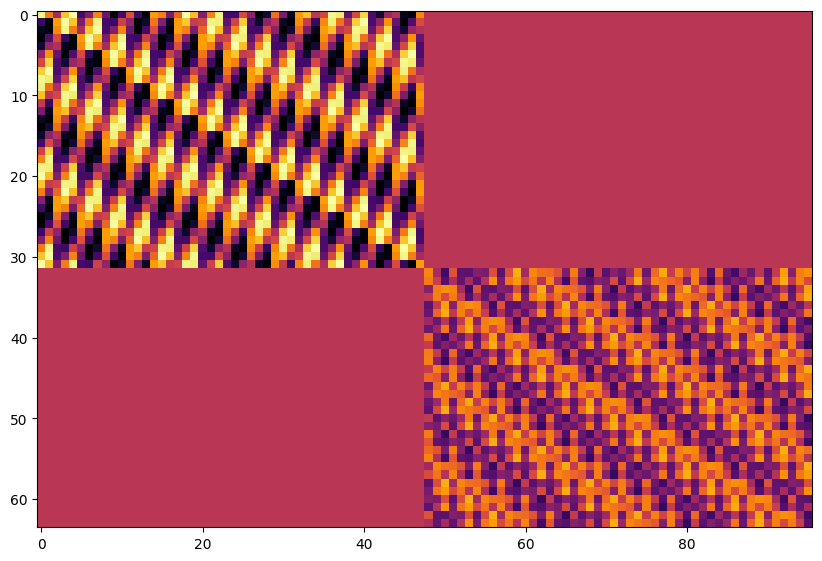

In [34]:
# Plot responce matrix (model)

plt.figure(figsize=(10, 10))
plt.imshow(responce_model.cpu().numpy(), cmap='inferno')
plt.show()

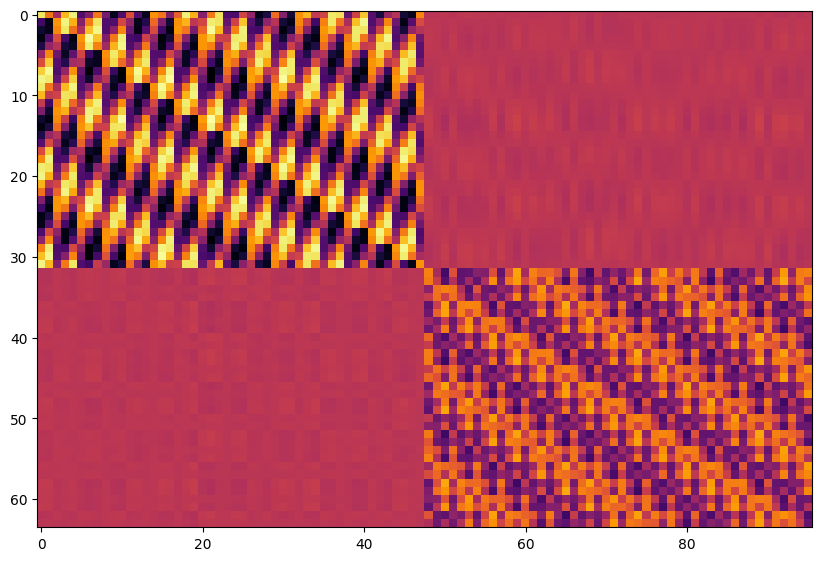

In [35]:
# Plot responce matrix (error)

plt.figure(figsize=(10, 10))
plt.imshow(responce_error.cpu().numpy(), cmap='inferno')
plt.show()

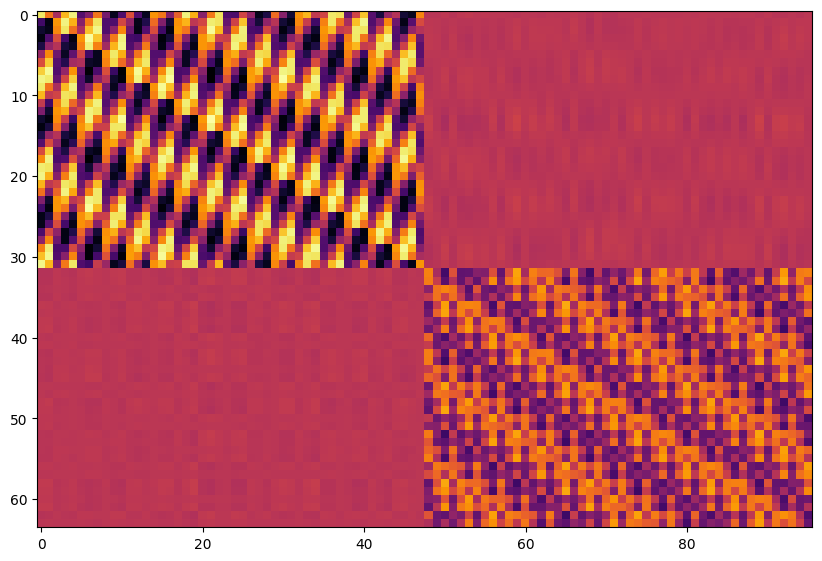

In [36]:
# Plot responce matrix (twiss)

plt.figure(figsize=(10, 10))
plt.imshow(responce_twiss.cpu().numpy(), cmap='inferno')
plt.show()

In [37]:
# Compare matrix norm

print(torch.linalg.matrix_norm(responce_error - responce_model))
print(torch.linalg.matrix_norm(responce_error - responce_twiss))

tensor(2.329383475610e+01, dtype=torch.float64)
tensor(1.051909931363e+00, dtype=torch.float64)


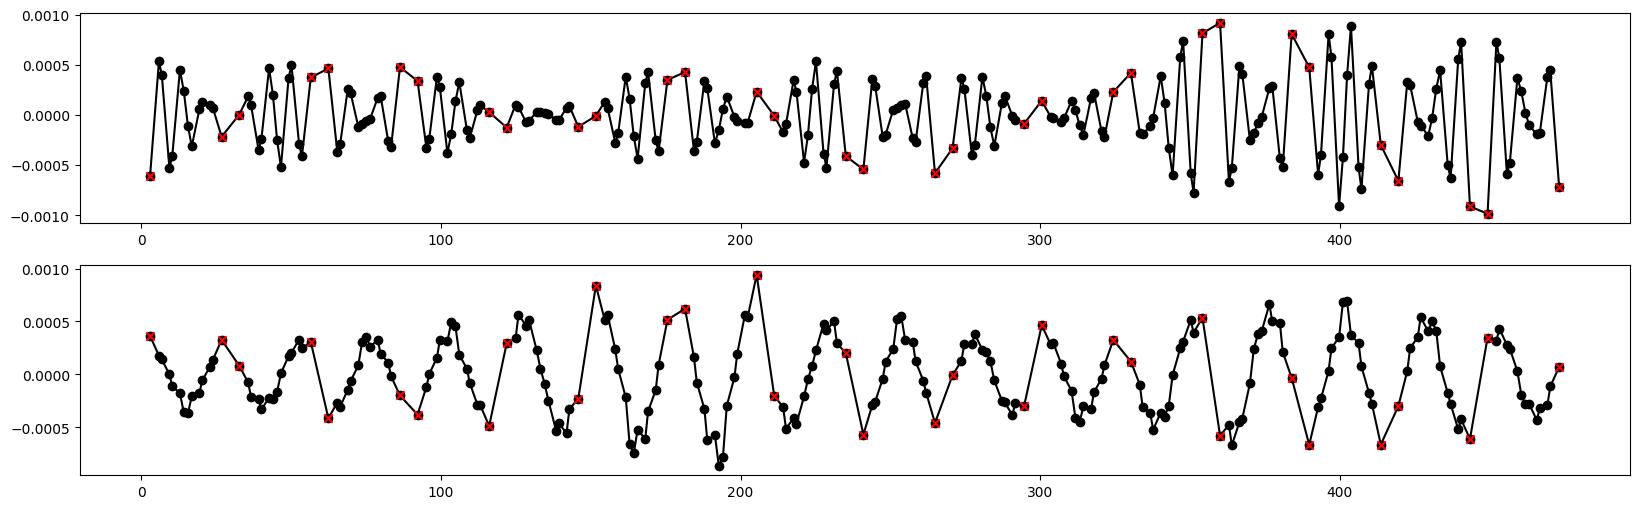

In [38]:
# Plot orbit at monitors with errors

# black -- orbit at all monitors
# red   -- orbit at ID monitors

x, _, y, _ = torch.clone(model.orbit.T)

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)

plt.show()

In [39]:
# Set fast correctors using model responce matrix

ax, ay = (torch.linalg.pinv(responce_model) @ torch.cat([x[lm], y[lm]])).reshape(-1, len(lc))
cx[lc] = -ax
cy[lc] = -ay

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)
model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

x_model, _, y_model, _ = torch.clone(model.orbit.T)

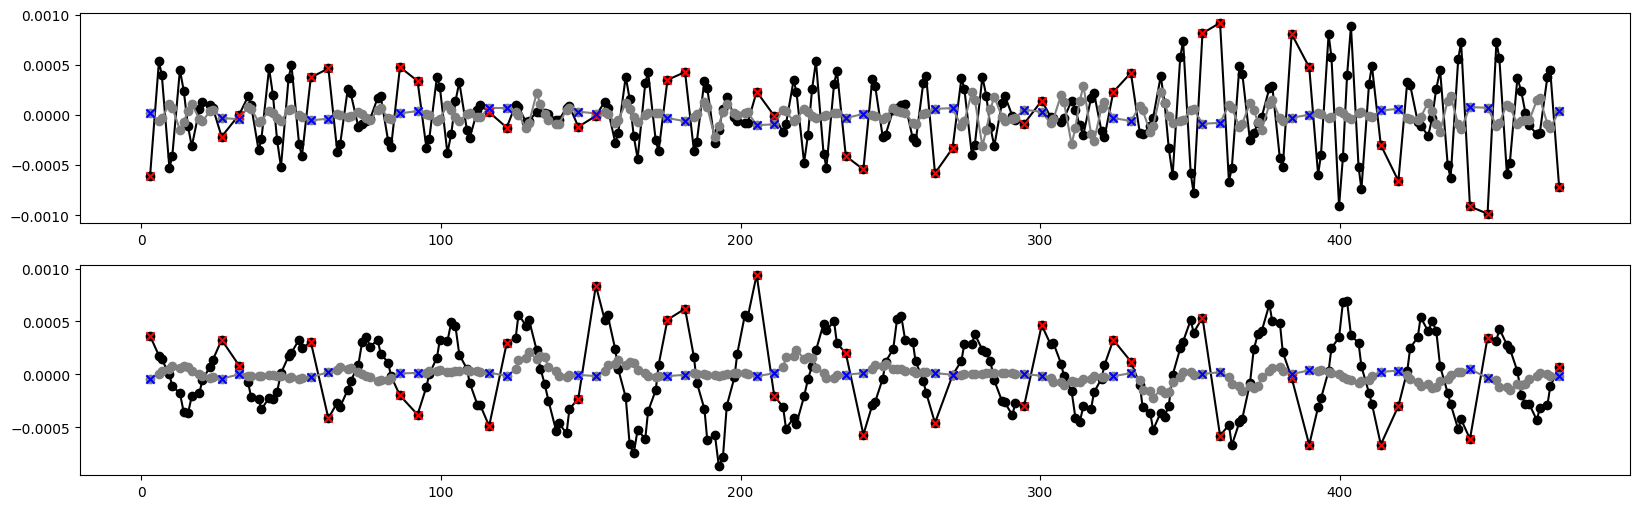

In [40]:
# Compare orbits

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x_model[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_model[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y_model[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_model[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

plt.show()

In [41]:
# Set fast correctors using error responce matrix

ax, ay = (torch.linalg.pinv(responce_error) @ torch.cat([x[lm], y[lm]])).reshape(-1, len(lc))
cx[lc] = -ax
cy[lc] = -ay

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)
model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

x_error, _, y_error, _ = torch.clone(model.orbit.T)

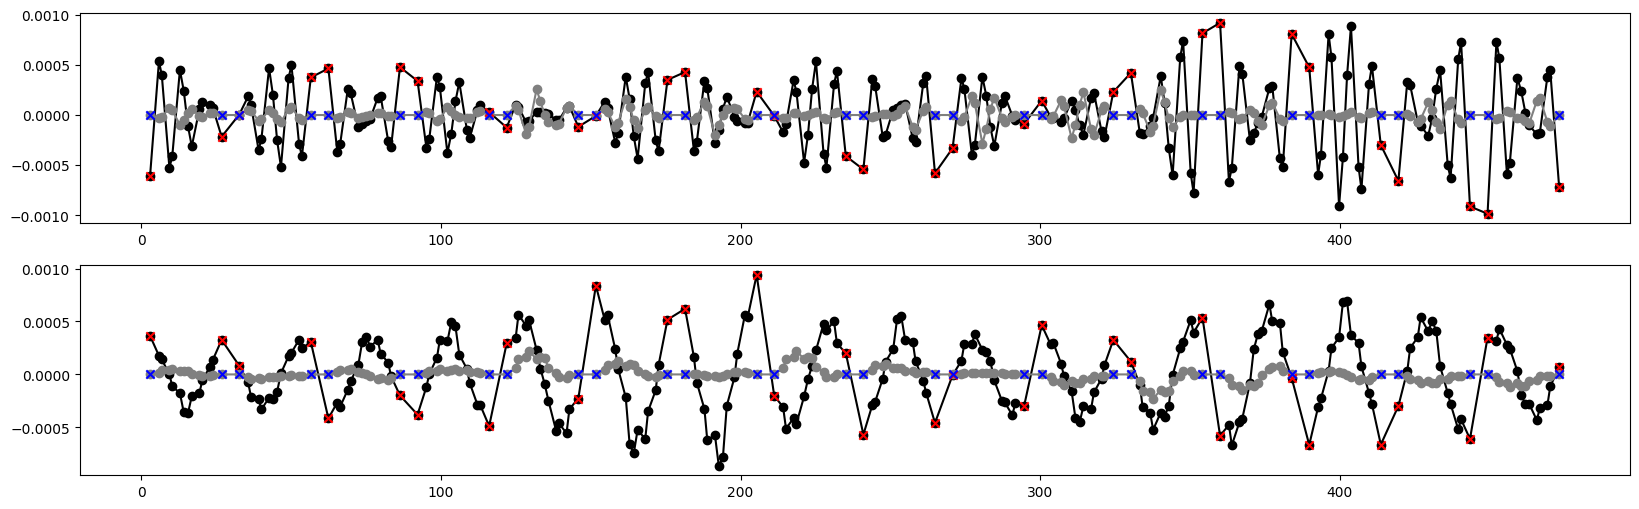

In [42]:
# Compare orbits

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x_error[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_error[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y_error[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_error[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

plt.show()

In [43]:
# Set fast correctors using twiss responce matrix

ax, ay = (torch.linalg.pinv(responce_twiss) @ torch.cat([x[lm], y[lm]])).reshape(-1, len(lc))
cx[lc] = -ax
cy[lc] = -ay

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)
model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

x_twiss, _, y_twiss, _ = torch.clone(model.orbit.T)

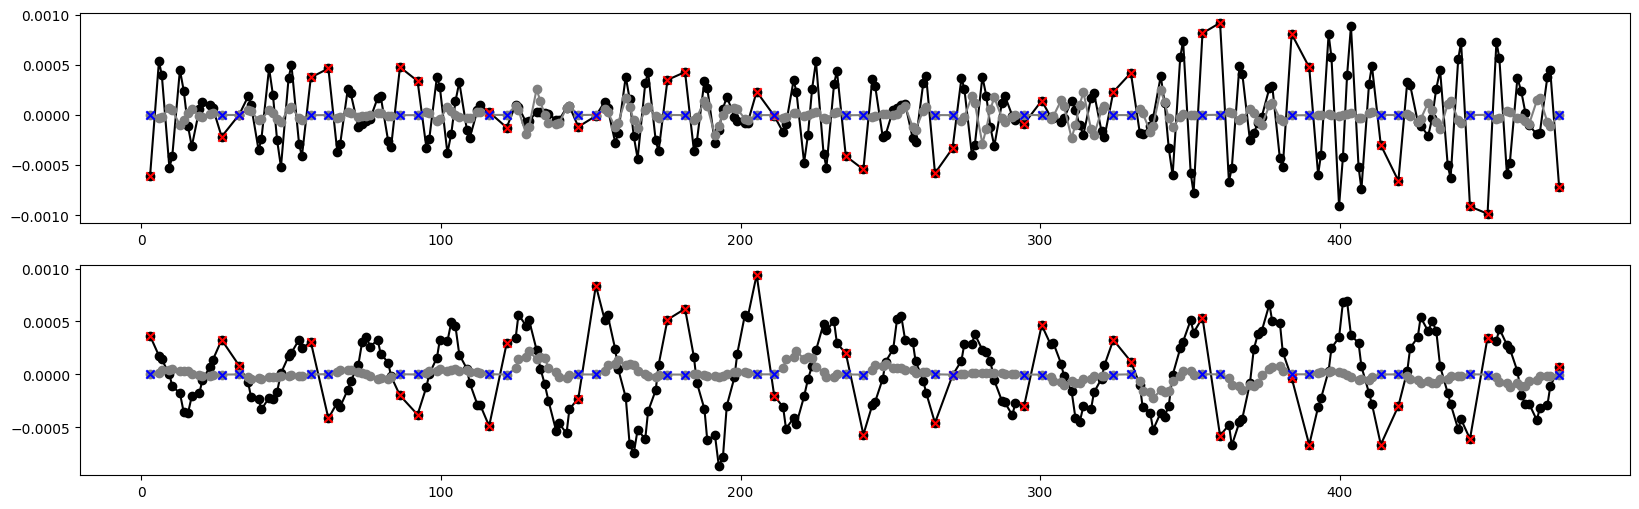

In [44]:
# Compare orbits

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x_twiss[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_twiss[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y_twiss[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_twiss[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

plt.show()

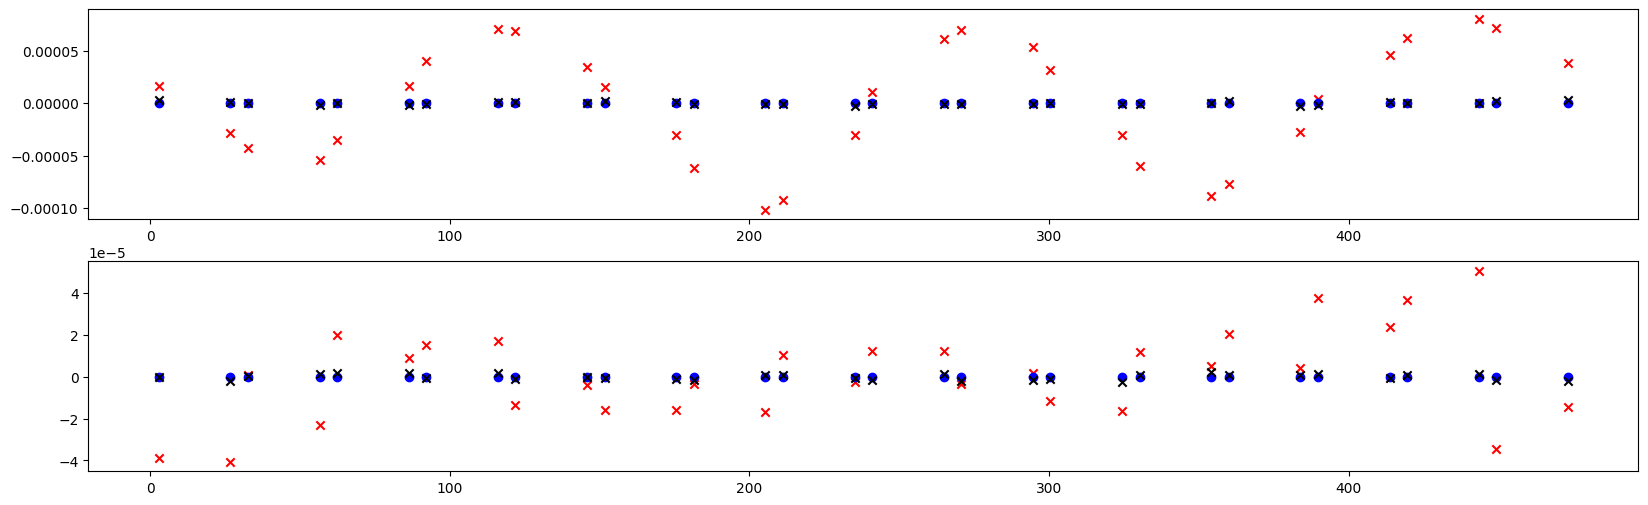

tensor(1.311702662997e-02, dtype=torch.float64)
tensor(1.547560782885e-03, dtype=torch.float64)
tensor(1.443828183828e-15, dtype=torch.float64)
tensor(3.356305627081e-05, dtype=torch.float64)

tensor(1.245209039378e-02, dtype=torch.float64)
tensor(5.438989847793e-04, dtype=torch.float64)
tensor(1.332243190051e-16, dtype=torch.float64)
tensor(3.815985485922e-05, dtype=torch.float64)



In [45]:
# Compare corrected orbits at ID monitors

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.scatter(model.time[lm].cpu().numpy(), x_model[lm].cpu().numpy(), color='red', marker='x', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_error[lm].cpu().numpy(), color='blue', marker='o', zorder=1)
ax.scatter(model.time[lm].cpu().numpy(), x_twiss[lm].cpu().numpy(), color='black', marker='x', zorder=2)

ax = plt.subplot(212)
ax.scatter(model.time[lm].cpu().numpy(), y_model[lm].cpu().numpy(), color='red', marker='x', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_error[lm].cpu().numpy(), color='blue', marker='o', zorder=1)
ax.scatter(model.time[lm].cpu().numpy(), y_twiss[lm].cpu().numpy(), color='black', marker='x', zorder=2)

plt.show()

print(x[lm].abs().sum())
print(x_model[lm].abs().sum())
print(x_error[lm].abs().sum())
print(x_twiss[lm].abs().sum())
print()

print(y[lm].abs().sum())
print(y_model[lm].abs().sum())
print(y_error[lm].abs().sum())
print(y_twiss[lm].abs().sum())
print()